before 30/11: weekends and weekdays were split to visualize any possible differences. No notable differences in trends in both cases were found, so they were merged!

the 'worst and best' performing stations are based on the on-time arrivals and their rankings are taken from https://www.ontimetrains.co.uk/stations

## This is demo for the assessment of one station's performance over the yearly available data

It includes a mean delay vs tph per platform as well as an outliers focus

In [6]:
# Import required libraries for station_view function
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime, timedelta
import sys
import matplotlib.pyplot as plt

# Ensure project root is in Python path
project_root = os.path.dirname(os.getcwd())  # Go up from demos to RDM_analysis
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Force reload of the module to get updated function signatures
import importlib
if 'rdmpy.outputs.analysis_tools' in sys.modules:
    import rdmpy.outputs.analysis_tools
    importlib.reload(rdmpy.outputs.analysis_tools)
    print(" Reloaded rdmpy.outputs.analysis_tools module")

if 'rdmpy.outputs.load_data' in sys.modules:
    import rdmpy.outputs.load_data
    importlib.reload(rdmpy.outputs.load_data)
    print("Reloaded rdmpy.outputs.load_data module")

try:
    from rdmpy.outputs.analysis_tools import (
        station_view_yearly_with_time_range,
        station_analysis_with_time_range
    )
    print(" Libraries imported successfully for station_view analysis")
    print("Comprehensive station analysis function imported: comprehensive_station_analysis")
    print("Wrapper functions imported: station_view_yearly_with_time_range, station_analysis_with_time_range")
except ImportError as e:
    print(f" Import error: {e}")
    print("Make sure you're running from the RDM_analysis directory")
except Exception as e:
    print(f" Error: {e}")

station_view_yearly function ready!
plot_trains_in_system_vs_delay function ready!
explore_delay_outliers function ready!
Merged station_view function defined successfully!
comprehensive_station_analysis function defined successfully!
Wrapper functions defined successfully!
 Reloaded rdmpy.outputs.analysis_tools module
Reloaded rdmpy.outputs.load_data module
 Libraries imported successfully for station_view analysis
Comprehensive station analysis function imported: comprehensive_station_analysis
Wrapper functions imported: station_view_yearly_with_time_range, station_analysis_with_time_range


Loading processed data (could take approx. 2min)

In [2]:
from rdmpy.outputs.load_data import load_processed_data

all_data = load_processed_data()

✅ Loaded 10,519,554 rows from 2606 files. Skipped 0.


NOTE: Set time_range=None to use all data, or specify a tuple like:

     1. time_range=('2024-01-15', '2024-01-15') for a single day
    
     2. time_range=('2024-01-01', '2024-06-30') for a date range

     3. time_range=('2024-01-15 08:00', '2024-01-15 17:00') for specific times

In [3]:
incident_summary, normal_summary = station_view_yearly_with_time_range(
    station_id='32000', 
    interval_minutes=60,
    time_range=None  # Change this to filter by time range
)


if incident_summary is not None and len(incident_summary) > 0:
    print("INCIDENT OPERATIONS:")
    print("-" * 40)
    print(incident_summary.to_string(index=False))
    print(f"Total incident periods: {len(incident_summary)}")
    
if normal_summary is not None and len(normal_summary) > 0:
    print("NORMAL OPERATIONS:")
    print("-" * 40)
    print(normal_summary.to_string(index=False))
    print(f"Total normal periods: {len(normal_summary)}")

print("=" * 80)

Loaded 38020 records from MO.parquet
Loaded 37618 records from TU.parquet
Loaded 37413 records from WE.parquet
Loaded 38125 records from TH.parquet
Loaded 35974 records from FR.parquet
Loaded 23015 records from SA.parquet
Loaded 7573 records from SU.parquet
Total combined records: 217738
Incident-related records: 7667
Normal operations records: 7213
INCIDENT OPERATIONS:
----------------------------------------
time_period  ontime_arrival_count  delayed_arrival_count  cancellation_count                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

### Example: Manchester Piccadilly

NOTE: Set time_range=None to use all data, or specify a tuple like:

     time_range=('2024-01-15', '2024-01-15') for a single day

     time_range=('2024-01-01', '2024-06-30') for a date range

     time_range=('2024-01-15 08:00', '2024-01-15 17:00') for specific times


COMPREHENSIVE ANALYSIS FOR STATION 32000

Running plot_trains_in_system_vs_delay analysis...
TRAINS IN SYSTEM vs DELAY ANALYSIS FOR STATION 32000
Platforms: 14, Assumed Dwell Time: 5 min
Trains in system NORMALIZED by 14 platforms
ONE POINT PER HOUR (same as plot_variable_relationships)
DELAY calculated ONLY from delayed trains (delay > 0)
Loaded 217738 total records for station 32000
Using 214264 arrived trains
Created 214264 valid timestamps
Processed 7377 hours total (weekdays and weekends merged)

STATION 32000 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 7377
  - Normalized trains in system range: 0.071 - 1.714 trains/platform
  - Mean delay range: 0.00 - 30.00 minutes
  - Overall mean delay: 6.08 minutes
  - Hours with delays > 0: 5994 (81.3%)
  - Correlation (trains in system vs delay): 0.254


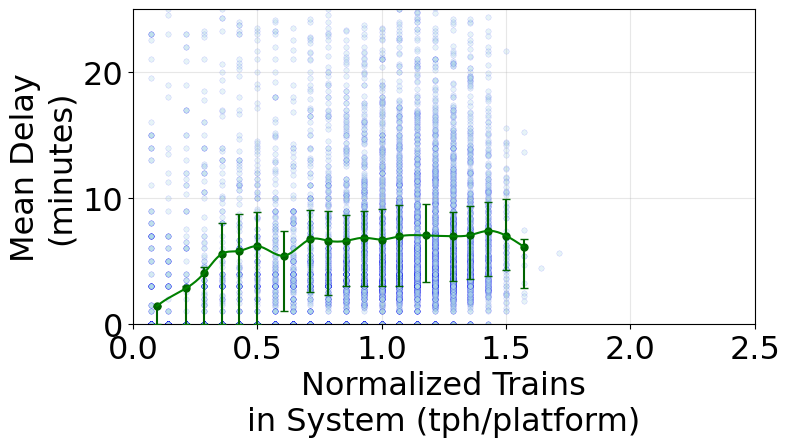


Running explore_delay_outliers analysis...
EXPLORING DELAY OUTLIERS FOR STATION 32000
Focus: Extreme delays and worst-case scenarios
 Processed 7499 hours with delay statistics


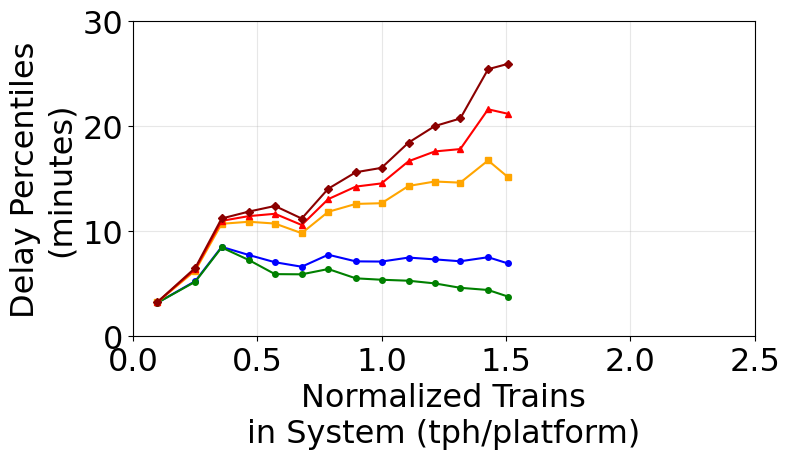

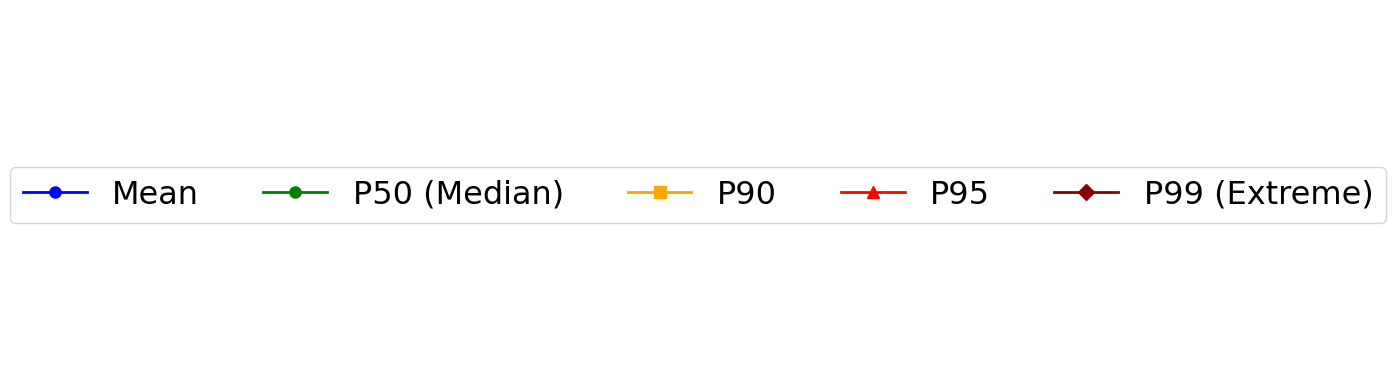


 EXTREME DELAY STATISTICS - STATION 32000
 TOP 5 WORST HOURS (by maximum delay):
  2024-11-02 21:00: Max=279.0min, Mean=25.2min, Trains=1.21/platform (35 delayed)
  2024-11-02 22:00: Max=279.0min, Mean=34.0min, Trains=1.14/platform (19 delayed)
  2024-11-02 23:00: Max=279.0min, Mean=62.2min, Trains=0.57/platform (8 delayed)
  2024-11-03 00:00: Max=279.0min, Mean=84.2min, Trains=0.50/platform (6 delayed)
  2024-11-03 01:00: Max=279.0min, Mean=279.0min, Trains=0.14/platform (1 delayed)
 OVERALL DELAY STATISTICS:
  - P90 delay across all hours: 12.02 min
  - P95 delay across all hours: 13.94 min
  - P99 delay across all hours: 15.52 min
  - Maximum single delay: 279.00 min
  - Hours with delays > 30 min: 1260 (16.8%)
 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 3550 (47.3%)
  - Mean delay in high load: 7.31 min
  - P95 delay in high load: 17.71 min

Running station_view analysis...
 Processed 7499 hours with comprehensive statistics



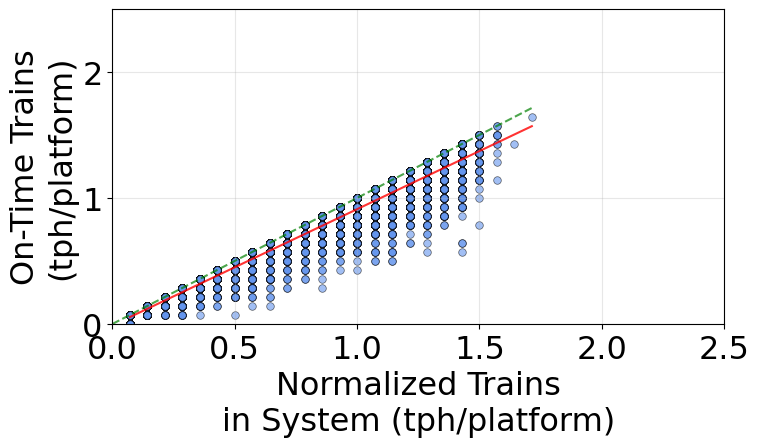

 Plot 1 complete: On-Time Performance vs System Load



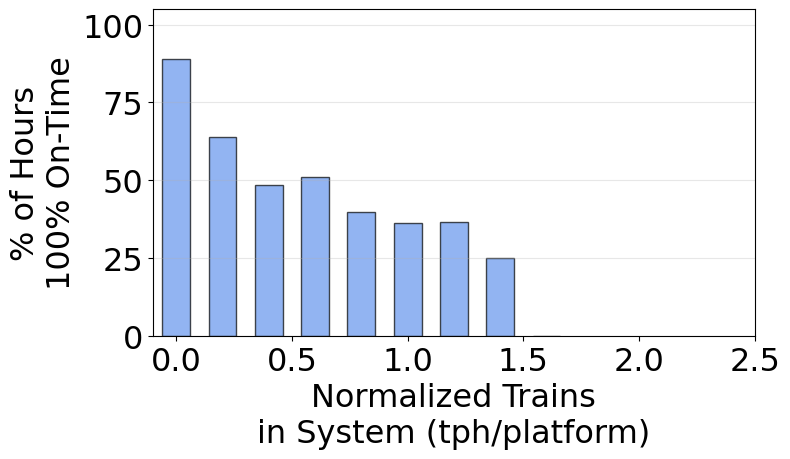

 Plot 2 complete: On-Time Performance Histogram



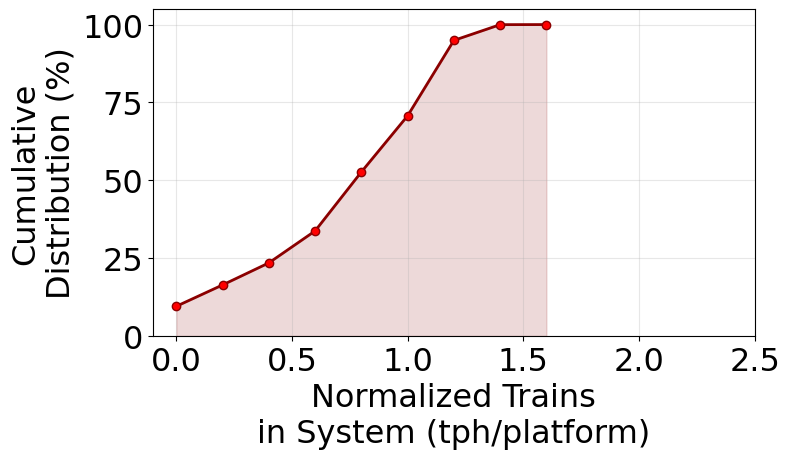

Plot 3 complete: Cumulative Distribution Function


COMPREHENSIVE STATION ANALYSIS SUMMARY FOR STATION 32000

ON-TIME PERFORMANCE:
  - Hours with 100% on-time: 3429 (45.7%)

SYSTEM LOAD:
  - Min normalized trains/platform: 0.07
  - Max normalized trains/platform: 1.71
  - Mean normalized trains/platform: 0.90


Creating combined visualization...


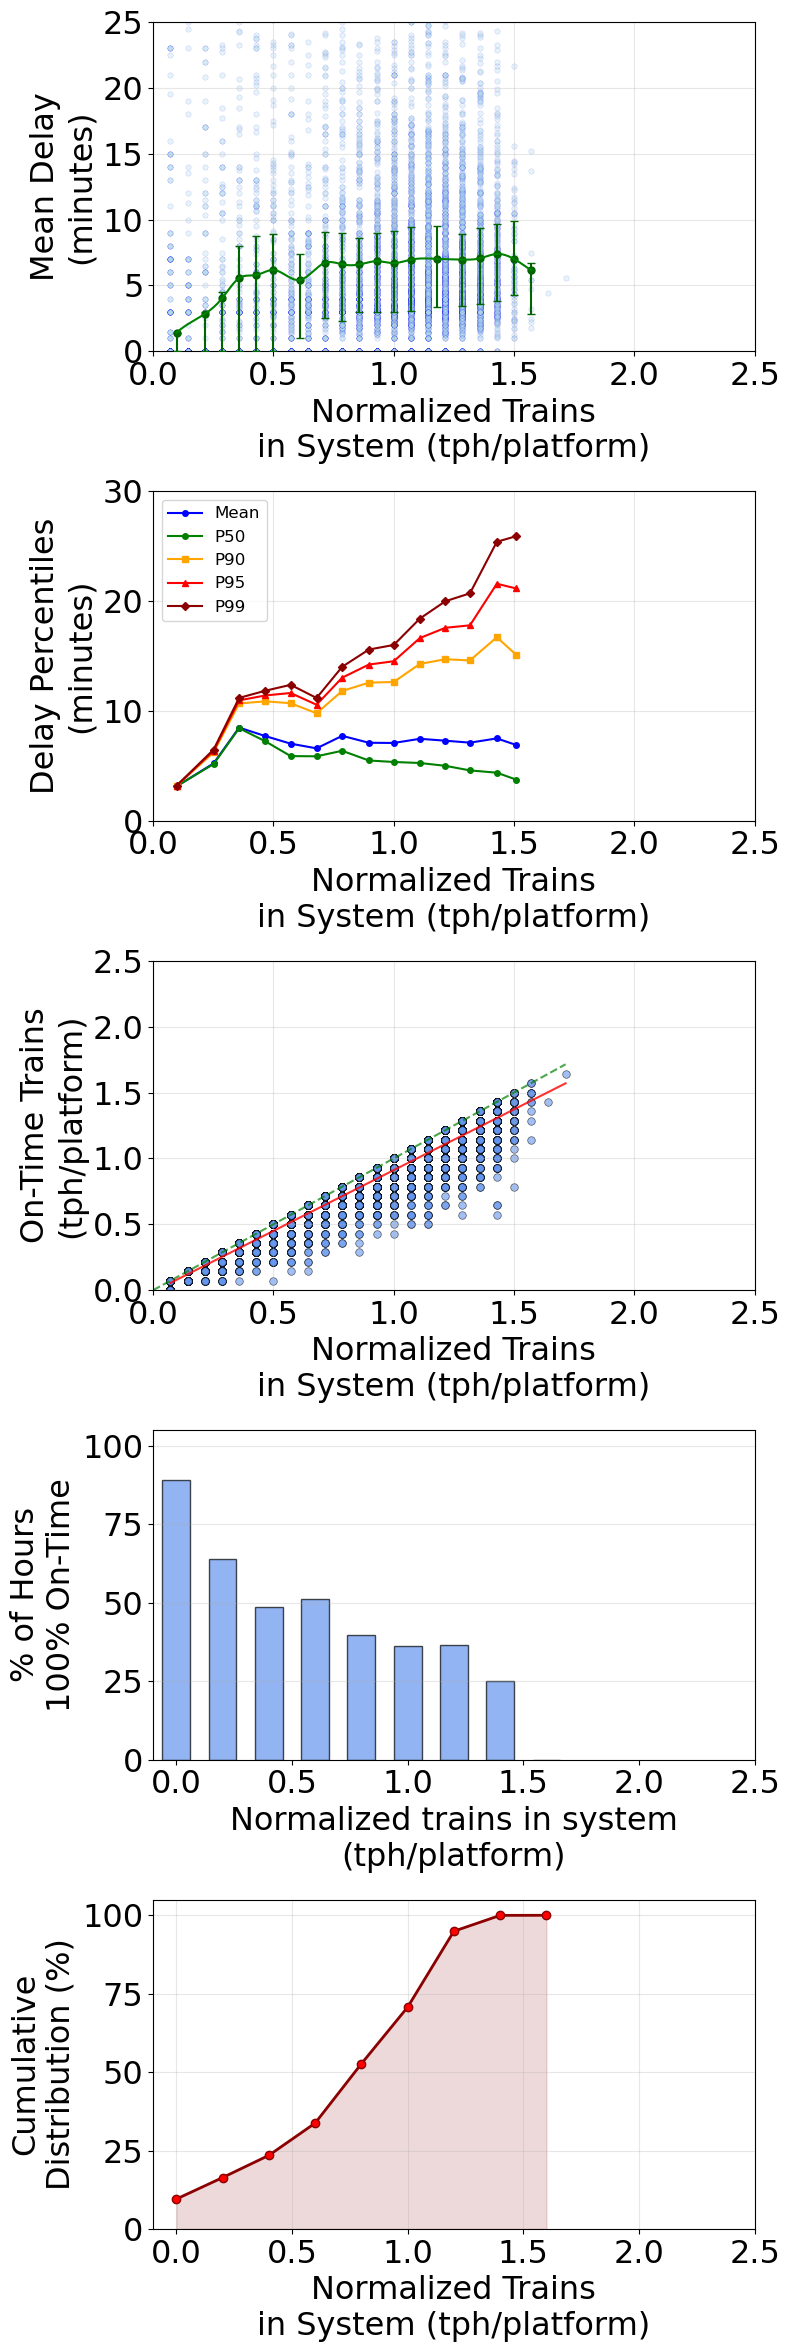


Comprehensive analysis complete!


In [4]:
comprehensive_results_32000 = station_analysis_with_time_range(
    station_id='32000',
    all_data=all_data,
    num_platforms=14,
    dwell_time_minutes=5,
    max_delay_percentile=98,
    time_range=None  # Change this to filter by time range
)

### For the same station, Manchester Piccadilly, but with a time range

c:\Users\39342\git\rdmpy\rdmpy\outputs\analysis_tools.py:4621: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  (all_data['EVENT_DATETIME'] <= end)].copy()


Filtered to 376370 records from 2024-01-01 00:00:00 to 2024-03-30 00:00:00

COMPREHENSIVE ANALYSIS FOR STATION 32000

Running plot_trains_in_system_vs_delay analysis...
TRAINS IN SYSTEM vs DELAY ANALYSIS FOR STATION 32000
Platforms: 14, Assumed Dwell Time: 5 min
Trains in system NORMALIZED by 14 platforms
ONE POINT PER HOUR (same as plot_variable_relationships)
DELAY calculated ONLY from delayed trains (delay > 0)
Loaded 4275 total records for station 32000
Using 3958 arrived trains
Created 3958 valid timestamps
Processed 907 hours total (weekdays and weekends merged)

STATION 32000 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 907
  - Normalized trains in system range: 0.071 - 1.214 trains/platform
  - Mean delay range: 1.00 - 37.00 minutes
  - Overall mean delay: 8.39 minutes
  - Hours with delays > 0: 907 (100.0%)
  - Correlation (trains in system vs delay): -0.010


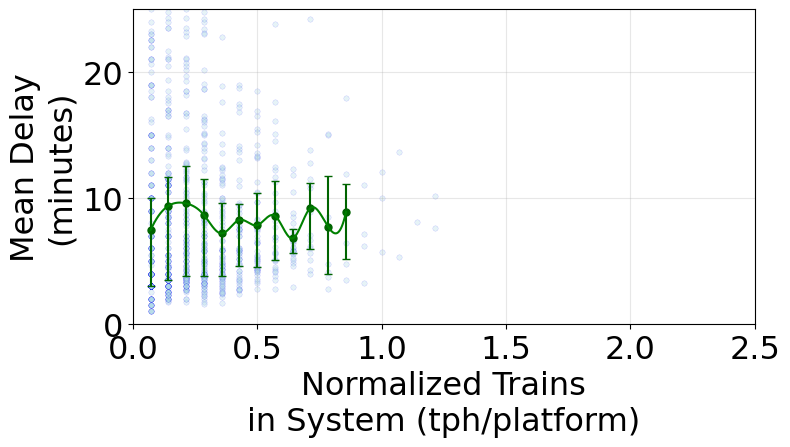


Running explore_delay_outliers analysis...
EXPLORING DELAY OUTLIERS FOR STATION 32000
Focus: Extreme delays and worst-case scenarios
 Processed 926 hours with delay statistics


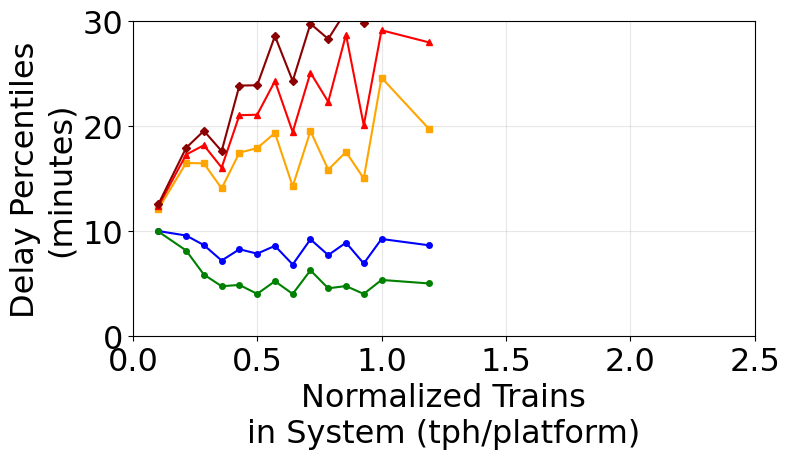

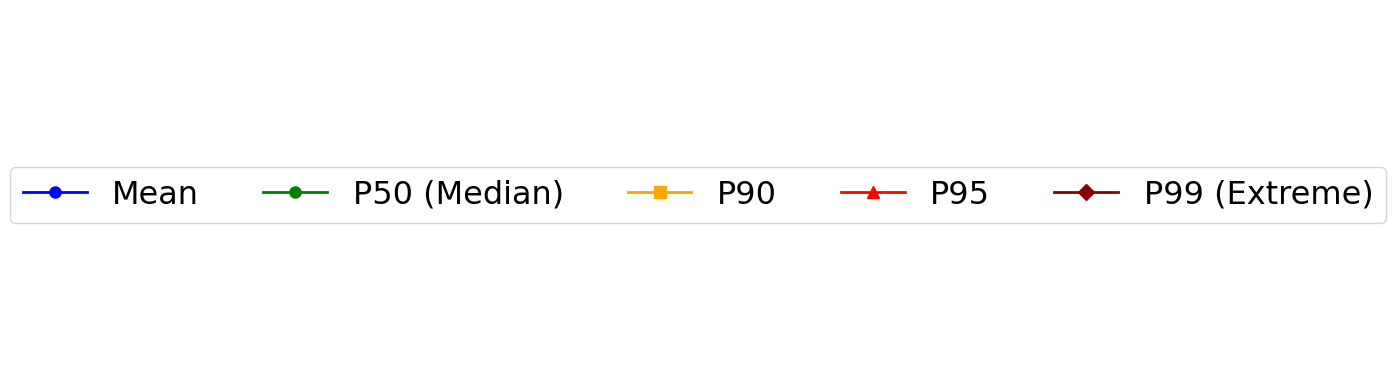


 EXTREME DELAY STATISTICS - STATION 32000
 TOP 5 WORST HOURS (by maximum delay):
  2024-03-04 16:00: Max=97.0min, Mean=17.6min, Trains=0.57/platform (11 delayed)
  2024-03-04 17:00: Max=97.0min, Mean=33.4min, Trains=0.29/platform (8 delayed)
  2024-03-04 18:00: Max=97.0min, Mean=27.9min, Trains=0.43/platform (9 delayed)
  2024-02-27 22:00: Max=77.0min, Mean=23.4min, Trains=0.29/platform (5 delayed)
  2024-02-27 23:00: Max=77.0min, Mean=24.0min, Trains=0.29/platform (4 delayed)
 OVERALL DELAY STATISTICS:
  - P90 delay across all hours: 14.61 min
  - P95 delay across all hours: 16.18 min
  - P99 delay across all hours: 17.47 min
  - Maximum single delay: 97.00 min
  - Hours with delays > 30 min: 160 (17.3%)
 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 5 (0.5%)
  - Mean delay in high load: 8.98 min
  - P95 delay in high load: 28.34 min

Running station_view analysis...
 Processed 926 hours with comprehensive statistics



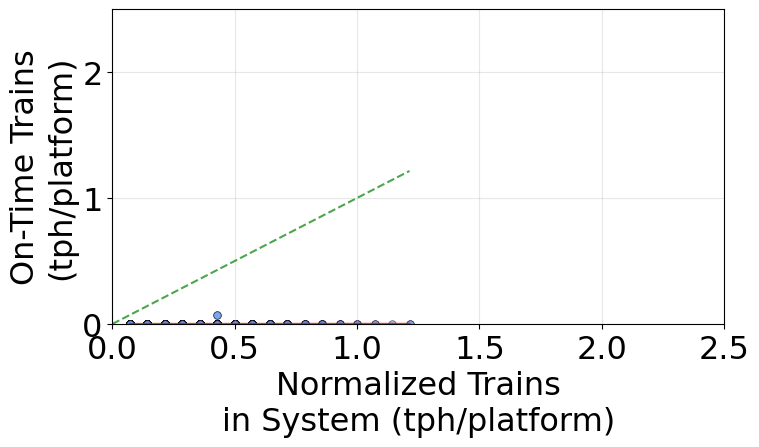

 Plot 1 complete: On-Time Performance vs System Load



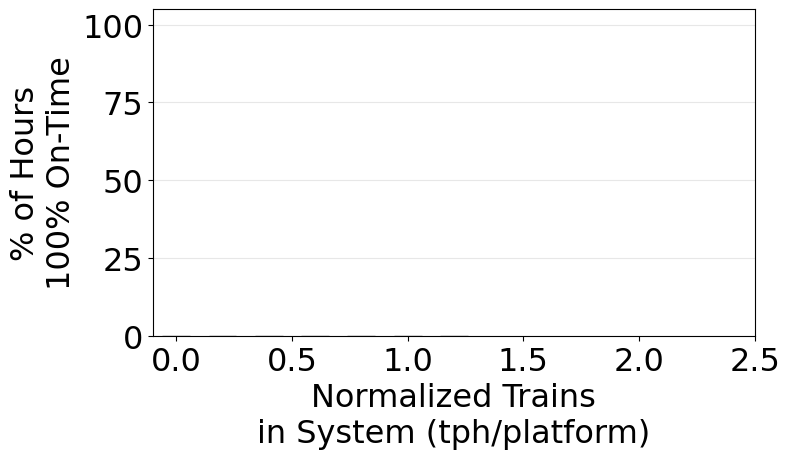

 Plot 2 complete: On-Time Performance Histogram



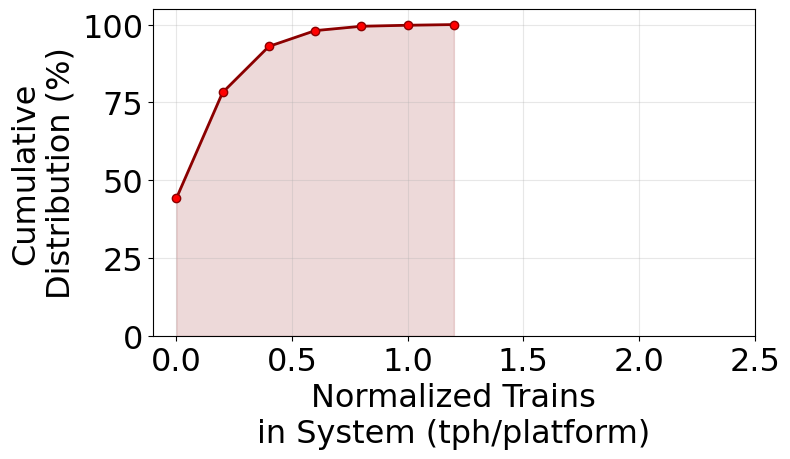

Plot 3 complete: Cumulative Distribution Function


COMPREHENSIVE STATION ANALYSIS SUMMARY FOR STATION 32000

ON-TIME PERFORMANCE:
  - Hours with 100% on-time: 0 (0.0%)

SYSTEM LOAD:
  - Min normalized trains/platform: 0.07
  - Max normalized trains/platform: 1.21
  - Mean normalized trains/platform: 0.26


Creating combined visualization...


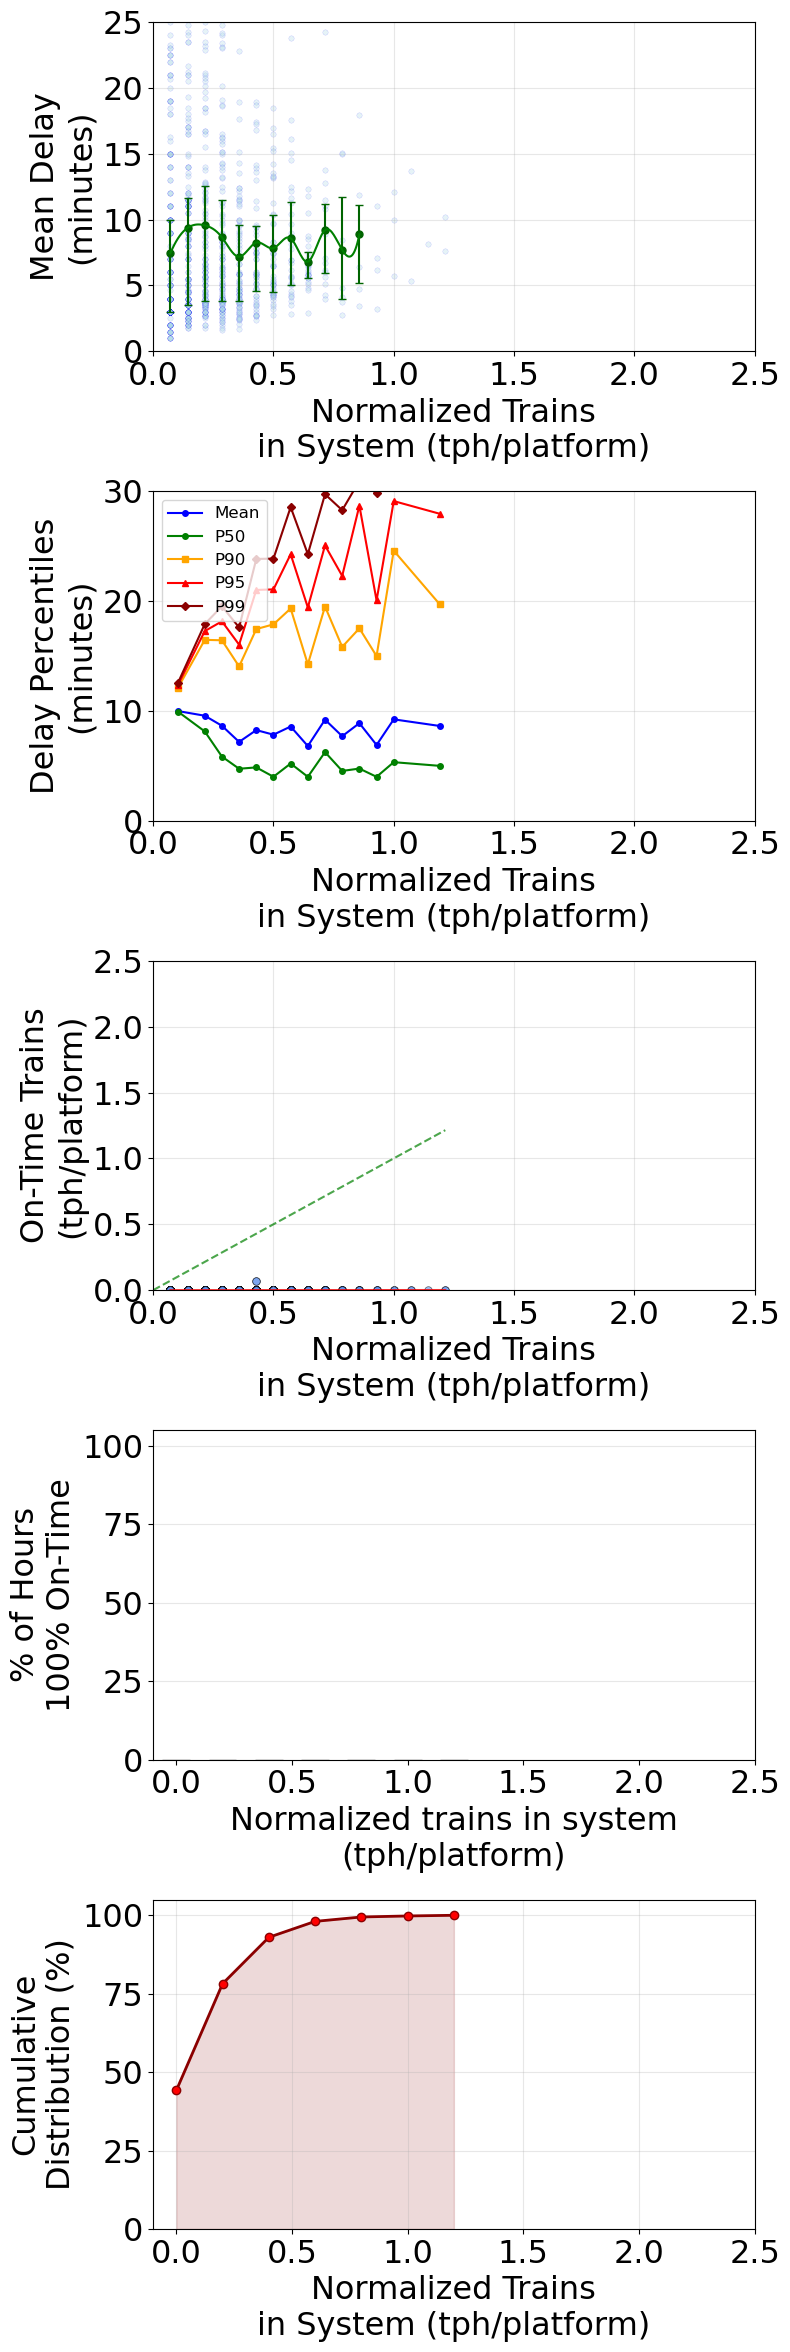


Comprehensive analysis complete!


In [7]:
comprehensive_results_32000_ranged = station_analysis_with_time_range(
    station_id='32000',
    all_data=all_data,
    num_platforms=14,
    dwell_time_minutes=5,
    max_delay_percentile=98,
    time_range=('2024-01-01', '2024-03-30')  # From Jan 1 to Mar 30, 2024
)